# Unidad 4 · Job shop: cuando cada trabajo trae su propia ruta

**Planta:** Conservas del Itata S.A. — taller de mantención
**Datos:** `DatosClases/4_Secuenciamiento/itata_jobshop.csv` — 6 trabajos que
pasan por las 4 máquinas del taller
**Solver:** Gurobi

---

## Qué se decide aquí

El taller de mantención tiene cuatro máquinas —M1 torno, M2 fresa, M3
soldadura, M4 tratamiento térmico— y seis trabajos en cola. Cada trabajo pasa
por las cuatro, pero **cada uno en su propio orden**: la pieza de T1 primero
se tornea y después se fresa; la de T2 primero se fresa y después se tornea.
Eso es un **job shop** (`Jm‖Cmax`), y es la diferencia entera con el cuaderno
04: allí los ocho lotes recorrían PREP → ENVASADO → AUTOCLAVE, todos en la
misma secuencia de etapas.

El cuaderno 04 terminó afirmando que flow shop y job shop son **el mismo
modelo**, y que lo que cambia son los datos. Acá se cobra esa afirmación: la
formulación disyuntiva se escribe otra vez, sin ninguna restricción nueva, y
lo único distinto es que la tabla `ruta` ya no tiene todas las filas iguales.

Hay una consecuencia inmediata que conviene anotar antes de empezar. En el
flow shop se podía discutir si exigir o no un **orden común a todas las
máquinas** (`prmu`). Acá esa pregunta ni siquiera se puede formular: si T1 va
a M1 en su primera operación y T2 va a M2 en la suya, "el orden de los
trabajos" no es una cosa que exista. El job shop no tiene versión
permutacional. Cada máquina decide su propio orden y ya.

## Lo que sí es nuevo: el big-M

En el cuaderno 04 el big-M se puso en `Σ p` y se siguió adelante. Acá se mira
con calma de dónde sale, por qué esa elección es válida, cómo conseguir una
mucho más ajustada, y —el punto incómodo— qué se gana realmente con eso en
esta instancia. La respuesta honesta no es la que uno esperaría, y por eso
vale la pena medirla en vez de repetir la receta.

## Cifras de referencia

| resultado | valor |
|---|---|
| cota por carga de máquina (M2) | **17,00 h** |
| cota por ruta más larga (T6) | 11,50 h |
| **cota inferior** | **17,00 h** |
| despacho no-demora (heurística) | 21,50 h |
| **óptimo `J4‖Cmax`** | **17,00 h** |

La cota inferior **se alcanza**. Eso dice algo muy concreto sobre el plan
óptimo: la máquina más cargada trabaja de la hora 0 a la hora 17 **sin un solo
hueco**. No hay nada que rescatar en ese taller, y se puede afirmar sin haber
probado ningún otro plan.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

js = pd.read_csv(datos("4_Secuenciamiento", "itata_jobshop.csv"))
js = js.sort_values(["trabajo", "orden_operacion"])

TRABAJOS = list(dict.fromkeys(js.trabajo))
MAQUINAS = sorted(js.maquina.unique())
NOMBRE_MAQ = {"M1": "torno", "M2": "fresa", "M3": "soldadura",
              "M4": "trat. térmico"}

# ruta[j] = [(maquina, p), ...] en el orden en que el trabajo j las visita
ruta = {j: [(x.maquina, float(x.p_h))
            for x in js[js.trabajo == j].itertuples()] for j in TRABAJOS}
n_ops = {j: len(ruta[j]) for j in TRABAJOS}
p = {(j, k): ruta[j][k][1] for j in TRABAJOS for k in range(n_ops[j])}
maq = {(j, k): ruta[j][k][0] for j in TRABAJOS for k in range(n_ops[j])}

print(f"{len(TRABAJOS)} trabajos · {len(MAQUINAS)} máquinas · "
      f"{len(p)} operaciones\n")
for m in MAQUINAS:
    print(f"  {m} = {NOMBRE_MAQ[m]}")

print("\nRuta de cada trabajo (máquina y horas, en orden):\n")
for j in TRABAJOS:
    print(f"  {j}:  " + "  ->  ".join(f"{m} ({pp:.1f} h)" for m, pp in ruta[j]))

6 trabajos · 4 máquinas · 24 operaciones

  M1 = torno
  M2 = fresa
  M3 = soldadura
  M4 = trat. térmico

Ruta de cada trabajo (máquina y horas, en orden):

  T1:  M1 (3.0 h)  ->  M2 (2.0 h)  ->  M3 (2.5 h)  ->  M4 (1.5 h)
  T2:  M2 (2.5 h)  ->  M1 (4.0 h)  ->  M4 (2.0 h)  ->  M3 (1.0 h)
  T3:  M3 (1.5 h)  ->  M4 (3.5 h)  ->  M1 (2.0 h)  ->  M2 (3.0 h)
  T4:  M1 (2.0 h)  ->  M3 (3.0 h)  ->  M2 (1.5 h)  ->  M4 (4.0 h)
  T5:  M4 (2.5 h)  ->  M2 (3.5 h)  ->  M3 (2.0 h)  ->  M1 (1.0 h)
  T6:  M2 (4.5 h)  ->  M3 (1.0 h)  ->  M4 (2.5 h)  ->  M1 (3.5 h)


## 1. Comprobar que esto NO es un flow shop

Parece una obviedad y no lo es: la diferencia entre los dos entornos vive
entera en los datos, así que hay que leerla de los datos. Si las seis
secuencias de máquinas fueran la misma lista, este cuaderno sería el 04 otra
vez con otros números.

In [2]:
secuencias = {j: [m for m, _pp in ruta[j]] for j in TRABAJOS}
es_flowshop = len({tuple(s) for s in secuencias.values()}) == 1

print("Secuencia de máquinas de cada trabajo:\n")
for j in TRABAJOS:
    print(f"  {j}:  " + " -> ".join(secuencias[j]))
print(f"\n¿Todas iguales (flow shop)? {es_flowshop}")
print("Seis rutas distintas: es un job shop, y la restricción de permutación")
print("del cuaderno 04 aquí no significa nada.")

pivot = js.pivot(index="trabajo", columns="maquina", values="p_h")[MAQUINAS]
print("\nHoras de proceso por trabajo y máquina (el ORDEN no se ve en esta tabla):\n")
print(pivot.to_string(float_format=lambda v: f"{v:,.1f}"))

Secuencia de máquinas de cada trabajo:

  T1:  M1 -> M2 -> M3 -> M4
  T2:  M2 -> M1 -> M4 -> M3
  T3:  M3 -> M4 -> M1 -> M2
  T4:  M1 -> M3 -> M2 -> M4
  T5:  M4 -> M2 -> M3 -> M1
  T6:  M2 -> M3 -> M4 -> M1

¿Todas iguales (flow shop)? False
Seis rutas distintas: es un job shop, y la restricción de permutación
del cuaderno 04 aquí no significa nada.

Horas de proceso por trabajo y máquina (el ORDEN no se ve en esta tabla):

maquina  M1  M2  M3  M4
trabajo                
T1      3.0 2.0 2.5 1.5
T2      4.0 2.5 1.0 2.0
T3      2.0 3.0 1.5 3.5
T4      2.0 1.5 3.0 4.0
T5      1.0 3.5 2.0 2.5
T6      3.5 4.5 1.0 2.5


## 2. Dos cotas inferiores, las mismas de siempre

Son las dos del cuaderno 04, y en un job shop siguen valiendo palabra por
palabra, porque ninguna de las dos usa que las rutas coincidan:

* **Carga de máquina.** Ninguna máquina termina antes de haber procesado todo
  lo que le toca: `Cmax ≥ max_m Σ_j p_jm`.
* **Ruta más larga.** Ningún trabajo termina antes de haber hecho sus cuatro
  operaciones, que van una detrás de otra por definición:
  `Cmax ≥ max_j Σ_k p_jk`.

Lo que **no** sobrevive es la tercera cota del flow shop, la que sumaba a la
carga de una etapa el ocio inevitable de antes y de después. Aquella usaba que
todos los lotes llegaban a la etapa `e` habiendo hecho exactamente las mismas
etapas previas. Acá cada trabajo llega a M2 con una historia distinta —T2
llega sin haber hecho nada, T5 llega después de 2,5 h en M4— así que el
`min_j` de "lo que viene antes" es cero para cualquier máquina que sea la
primera parada de algún trabajo, y la cota se degrada hasta volverse la
primera. Es un buen ejemplo de una cota que se cae al generalizar el entorno,
y de por qué conviene saber de dónde salió cada una.

In [3]:
carga = {m: float(js[js.maquina == m].p_h.sum()) for m in MAQUINAS}
largo_ruta = {j: sum(pp for _m, pp in ruta[j]) for j in TRABAJOS}

lb_carga = max(carga.values())
maq_critica = max(carga, key=carga.get)
lb_ruta = max(largo_ruta.values())
trab_critico = max(largo_ruta, key=largo_ruta.get)
LB = max(lb_carga, lb_ruta)

print("Carga total de cada máquina (h):")
for m in MAQUINAS:
    marca = "  <- la más cargada" if m == maq_critica else ""
    print(f"  {m} ({NOMBRE_MAQ[m]:13s}) {carga[m]:6.2f}{marca}")

print("\nLargo de la ruta de cada trabajo (h):")
for j in TRABAJOS:
    marca = "  <- la más larga" if j == trab_critico else ""
    print(f"  {j}  {largo_ruta[j]:6.2f}{marca}")

print(f"\ncota por carga de máquina : {lb_carga:6.2f} h  ({maq_critica})")
print(f"cota por ruta más larga   : {lb_ruta:6.2f} h  ({trab_critico})")
print(f"\nCOTA INFERIOR = {LB:.2f} h")
print("\nManda la carga de máquina, y por bastante. Si el óptimo llega a tocar")
print(f"esta cota, {maq_critica} no tendrá un solo minuto libre entre la hora 0 y la {LB:.0f}.")

Carga total de cada máquina (h):
  M1 (torno        )  15.50
  M2 (fresa        )  17.00  <- la más cargada
  M3 (soldadura    )  11.00
  M4 (trat. térmico)  16.00

Largo de la ruta de cada trabajo (h):
  T1    9.00
  T2    9.50
  T3   10.00
  T4   10.50
  T5    9.00
  T6   11.50  <- la más larga

cota por carga de máquina :  17.00 h  (M2)
cota por ruta más larga   :  11.50 h  (T6)

COTA INFERIOR = 17.00 h

Manda la carga de máquina, y por bastante. Si el óptimo llega a tocar
esta cota, M2 no tendrá un solo minuto libre entre la hora 0 y la 17.


## 3. Un calendario factible sin solver: despacho no-demora

Antes del MIP conviene tener **algún** plan que funcione. Sirve para tres
cosas distintas y las tres importan: da una cota superior, da un punto de
comparación para el óptimo, y —lo que interesa en la sección siguiente— da un
big-M válido y mucho más chico que el trivial.

La regla es la más simple que existe. En cada paso se miran las operaciones
que están **disponibles** (la operación anterior de su trabajo ya terminó) y
se programa la que **puede empezar antes**, empatando por tiempo de proceso.
Se llama *no-demora* porque nunca deja una máquina parada teniendo trabajo
listo para ella.

No es óptima ni pretende serlo. De hecho, en un job shop puede ser
arbitrariamente mala: existen instancias donde **todo** calendario no-demora
es peor que el óptimo, porque a veces conviene dejar una máquina parada a
propósito esperando un trabajo que viene. Pero es factible, y eso es lo único
que se le está pidiendo.

In [4]:
def despacho_no_demora():
    """Programa la operación disponible que pueda empezar antes. Empate: SPT."""
    libre = {m: 0.0 for m in MAQUINAS}       # instante en que se desocupa m
    fin_trabajo = {j: 0.0 for j in TRABAJOS}  # fin de la última op. hecha de j
    siguiente = {j: 0 for j in TRABAJOS}      # índice de su próxima operación
    filas = []
    for _ in range(len(p)):
        candidatas = [(max(libre[maq[j, siguiente[j]]], fin_trabajo[j]),
                       p[j, siguiente[j]], j)
                      for j in TRABAJOS if siguiente[j] < n_ops[j]]
        t_ini, pp, j = min(candidatas)
        k = siguiente[j]
        m = maq[j, k]
        libre[m] = fin_trabajo[j] = t_ini + pp
        siguiente[j] += 1
        filas.append({"trabajo": j, "k": k + 1, "maquina": m,
                      "inicio": t_ini, "fin": t_ini + pp})
    return pd.DataFrame(filas)


heur = despacho_no_demora()
UB = float(heur.fin.max())
print(f"Despacho no-demora: Cmax = {UB:.2f} h")
print(f"  cota inferior {LB:.2f} h  ->  exceso {UB - LB:.2f} h "
      f"({100*(UB/LB - 1):.1f} %)")
print("\nHay 4,5 h de holgura entre lo que este plan logra y lo que la cota")
print("dice que podría lograrse. Todavía no se sabe si esa holgura es real")
print("(existe un plan mejor) o si la cota es floja. Eso lo decide el MIP.")

Despacho no-demora: Cmax = 21.50 h
  cota inferior 17.00 h  ->  exceso 4.50 h (26.5 %)

Hay 4,5 h de holgura entre lo que este plan logra y lo que la cota
dice que podría lograrse. Todavía no se sabe si esa holgura es real
(existe un plan mejor) o si la cota es floja. Eso lo decide el MIP.


## 4. El big-M: de dónde sale y cuánto conviene apretarlo

La disyunción que ordena dos operaciones `a` y `b` en la misma máquina es

$$S_b \ge S_a + p_a - M\,(1 - z_{ab}), \qquad
  S_a \ge S_b + p_b - M\,z_{ab}$$

Cuando `z_ab = 1` la primera queda activa y la segunda tiene que quedar
**desactivada**, es decir, satisfecha automáticamente para cualquier
calendario que nos interese. Eso es lo que `M` compra. Y "cualquier calendario
que nos interese" es la frase que hay que precisar, porque de ahí sale la
condición exacta:

> `M` es válido si `M ≥ S_b + p_b − S_a` para todo par y **todo calendario
> óptimo**. Basta con `M ≥` cualquier cota superior del horizonte, porque
> `S_b + p_b ≤ Cmax` y `S_a ≥ 0`.

Así que **cualquier cota superior del makespan sirve de big-M**, y a partir de
ahí es solo cuestión de conseguir la más chica que se pueda demostrar:

| candidato | valor | por qué es válido |
|---|---|---|
| `Σ p` (el trivial) | 59,50 h | hacer las 24 operaciones una detrás de otra, sin solapar nada, es factible |
| Cmax del despacho no-demora | 21,50 h | es un calendario factible, así que su makespan es una cota superior |

El trivial es casi **tres veces** el ajustado, y no cuesta nada reemplazarlo:
la heurística de la sección 3 ya estaba corrida. La regla práctica es esa —el
big-M no se elige "grande", se **calcula** a partir de una solución factible—
y es la misma que se usa para acotar el horizonte del modelo indexado en el
tiempo del cuaderno 06.

Lo que **no** hay que hacer es poner un `M` enorme "por si acaso": con `M` de
10⁶ la relajación lineal se vuelve inútil y el solver empieza a arrastrar
errores numéricos de verdad, no teóricos.

In [5]:
M_trivial = sum(p.values())
M_ajustado = UB

print(f"big-M trivial  (Σ p)                    = {M_trivial:6.2f} h")
print(f"big-M ajustado (despacho no-demora)     = {M_ajustado:6.2f} h")
print(f"  reducción: {100*(1 - M_ajustado/M_trivial):.1f} %")

big-M trivial  (Σ p)                    =  59.50 h
big-M ajustado (despacho no-demora)     =  21.50 h
  reducción: 63.9 %


### Y ahora la parte incómoda: medirlo

La receta dice que un big-M ajustado mejora la relajación lineal y acelera al
solver. Es una afirmación sobre un modelo concreto, así que se comprueba en el
modelo concreto. Se resuelven las dos relajaciones lineales y se comparan.

La sección 5 arma el modelo; acá se usa esa misma función con los dos valores
de `M` y se mira el resultado antes de haber dicho nada sobre el óptimo.

In [6]:
def modelo_jobshop(M, relajado=False, tiempo_limite=120.0, limpio=False):
    """J4||Cmax disyuntivo. `relajado=True` deja las binarias en [0,1].

    `limpio=True` apaga presolve, cortes y heurísticas: sirve para comparar
    formulaciones sin que el solver tape la diferencia con su propia maquinaria.
    """
    m = gp.Model("J4-Cmax")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9
    m.Params.Seed = 0
    if limpio:
        m.Params.Presolve = 0
        m.Params.Cuts = 0
        m.Params.Heuristics = 0.0

    S = m.addVars(list(p), lb=0.0, ub=M, name="S")

    # (1) ruta: la operación k+1 de un trabajo no empieza antes de que termine
    #     la k. Esta es la única restricción donde entra el orden propio de cada
    #     trabajo, y es donde vive TODA la diferencia con el flow shop.
    for j in TRABAJOS:
        for k in range(n_ops[j] - 1):
            m.addConstr(S[j, k + 1] >= S[j, k] + p[j, k], name=f"ruta[{j},{k}]")

    # (2) recurso: los pares se arman por MÁQUINA, agrupando operaciones de
    #     trabajos distintos que compiten por ella.
    por_maquina = {}
    for (j, k), mm in maq.items():
        por_maquina.setdefault(mm, []).append((j, k))
    pares = [(mm, a, b) for mm, lst in por_maquina.items()
             for i, a in enumerate(lst) for b in lst[i + 1:]]
    tipo = GRB.CONTINUOUS if relajado else GRB.BINARY
    z = m.addVars(pares, vtype=tipo, lb=0.0, ub=1.0, name="z")
    for (mm, a, b) in pares:
        m.addConstr(S[b] >= S[a] + p[a] - M * (1 - z[mm, a, b]),
                    name=f"disy1[{mm},{a},{b}]")
        m.addConstr(S[a] >= S[b] + p[b] - M * z[mm, a, b],
                    name=f"disy2[{mm},{a},{b}]")

    Cmax = m.addVar(lb=0.0, ub=M, name="Cmax")
    m.addConstrs((Cmax >= S[j, n_ops[j] - 1] + p[j, n_ops[j] - 1]
                  for j in TRABAJOS), name="cmax")
    m.setObjective(Cmax, GRB.MINIMIZE)
    return m, S, z


print("Relajación lineal (binarias sueltas en [0,1]):\n")
for etiqueta, M in [("Σ p", M_trivial), ("no-demora", M_ajustado)]:
    rel, _S, _z = modelo_jobshop(M, relajado=True)
    rel.optimize()
    print(f"  M = {M:6.2f} ({etiqueta:10s})  ->  LP = {rel.ObjVal:6.2f} h")

print(f"\nLa misma cota, {lb_ruta:.2f} h, con los dos big-M. No es un error.")

Relajación lineal (binarias sueltas en [0,1]):

Restricted license - for non-production use only - expires 2027-11-29


  M =  59.50 (Σ p       )  ->  LP =  11.50 h
  M =  21.50 (no-demora )  ->  LP =  11.50 h

La misma cota, 11.50 h, con los dos big-M. No es un error.


### Por qué la relajación no se mueve, y qué se aprende de eso

`11,50 h` es exactamente `lb_ruta`, la ruta del trabajo más largo. La
relajación lineal de esta formulación **no ve las máquinas en absoluto**, y la
razón es aritmética: poniendo todas las binarias en `z = 1/2`, las dos
desigualdades de cada par se convierten en

$$S_b \ge S_a + p_a - \tfrac{M}{2}, \qquad S_a \ge S_b + p_b - \tfrac{M}{2}$$

y ambas son vacías apenas `M/2 ≥ max p_jk = 4,5 h`, o sea apenas `M ≥ 9 h`.
Con `M = 9` el modelo **entero** ya sería infactible, porque el horizonte
necesita 17 h. Así que en el rango de valores **válidos** de `M` —de 17 h para
arriba— la relajación lineal siempre deja todas las disyunciones colgando y se
queda con la única cota que las precedencias de ruta le dan sola.

Esa es la debilidad estructural de la formulación disyuntiva con big-M, y no
se arregla apretando `M`: se arregla cambiando de formulación (indexada en el
tiempo, como el cuaderno 06) o dejando que el solver agregue cortes.

La conclusión práctica no es "el big-M ajustado da igual". Es más fina:

* Calcularlo es **gratis** —la heurística ya estaba corrida— y **nunca**
  empeora la validez, así que se hace igual.
* El beneficio es **dependiente de la instancia**, y afirmarlo sin medirlo es
  exactamente el tipo de creencia que este curso pide no tener. En esta
  instancia el beneficio es **cero**, y decirlo vale más que ocultarlo.
* Donde el big-M ajustado sí paga siempre es en la **estabilidad numérica**.
  Entre 21,5 y 10⁶ la diferencia no es de nodos: es de si el solver confía o
  no en sus propias tolerancias.

In [7]:
print("Mismo experimento sobre el MIP, con presolve, cortes y heurísticas")
print("APAGADOS para que no tapen la diferencia:\n")
filas_bigM = []
for etiqueta, M in [("Σ p", M_trivial), ("no-demora", M_ajustado)]:
    mm, _S, _z = modelo_jobshop(M, limpio=True)
    t0 = time.perf_counter()
    mm.optimize()
    seg = time.perf_counter() - t0
    filas_bigM.append({"big-M": etiqueta, "M": M, "Cmax": mm.ObjVal,
                       "nodos": int(mm.NodeCount), "segundos": seg})
bigM_df = pd.DataFrame(filas_bigM)
print(bigM_df.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print("\nMismo óptimo y prácticamente los mismos nodos. Medido, no supuesto.")

Mismo experimento sobre el MIP, con presolve, cortes y heurísticas
APAGADOS para que no tapen la diferencia:

    big-M     M  Cmax  nodos  segundos
      Σ p 59.50 17.00    119      0.02
no-demora 21.50 17.00    127      0.01

Mismo óptimo y prácticamente los mismos nodos. Medido, no supuesto.


## 5. El MIP disyuntivo `J4‖Cmax`

El modelo completo, ahora con las binarias de verdad y toda la maquinaria del
solver encendida. Vale la pena leer el conteo de pares, porque es lo único que
cambió respecto del cuaderno 04:

En el flow shop general había una binaria por par de lotes **y por etapa**.
Acá el criterio es el mismo —una binaria por par de operaciones que compiten
por la misma máquina— pero los pares se arman agrupando por máquina, no por
etapa. Como cada trabajo visita cada máquina exactamente una vez, cada máquina
recibe 6 operaciones y aporta `6·5/2 = 15` pares. Cuatro máquinas: **60
binarias**.

Que el conteo salga igual que en un flow shop de 6 lotes y 4 etapas no es
casualidad ni coincidencia: es la afirmación del cuaderno 04 hecha número. El
modelo no sabe si las rutas coinciden.

In [8]:
def resolver_jobshop(M, tiempo_limite=120.0):
    m, S, z = modelo_jobshop(M, tiempo_limite=tiempo_limite)
    t0 = time.perf_counter()
    m.optimize()
    seg = time.perf_counter() - t0

    asig = pd.DataFrame([
        {"trabajo": j, "k": k + 1, "maquina": maq[j, k],
         "inicio": S[j, k].X, "fin": S[j, k].X + p[j, k], "p_h": p[j, k]}
        for (j, k) in p])
    estado = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
              GRB.INFEASIBLE: "INFEASIBLE"}.get(m.Status, f"STATUS_{m.Status}")
    return {"Cmax": m.ObjVal, "cota": m.ObjBound, "gap_%": 100 * m.MIPGap,
            "estado": estado, "vars": m.NumVars, "binarias": m.NumBinVars,
            "restr": m.NumConstrs, "nodos": int(m.NodeCount), "seg": seg,
            "asignaciones": asig}


sol = resolver_jobshop(M_ajustado)

print(f"{'estado':>10s} {'Cmax':>8s} {'cota':>8s} {'gap %':>8s} "
      f"{'vars':>6s} {'binarias':>9s} {'restr':>7s} {'nodos':>7s} {'seg':>8s}")
print(f"{sol['estado']:>10s} {sol['Cmax']:8.2f} {sol['cota']:8.2f} "
      f"{sol['gap_%']:8.4f} {sol['vars']:6d} {sol['binarias']:9d} "
      f"{sol['restr']:7d} {sol['nodos']:7d} {sol['seg']:8.3f}")

print(f"\nóptimo {sol['Cmax']:.2f} h   ·   cota inferior {LB:.2f} h   ·   "
      f"despacho no-demora {UB:.2f} h")
print(f"La heurística estaba {UB - sol['Cmax']:.2f} h por encima "
      f"({100*(UB/sol['Cmax'] - 1):.1f} %). La holgura de la sección 3 era real:")
print("había un plan mejor, y la cota no era floja.")

    estado     Cmax     cota    gap %   vars  binarias   restr   nodos      seg
   OPTIMAL    17.00    17.00   0.0000     85        60     144       1    0.074

óptimo 17.00 h   ·   cota inferior 17.00 h   ·   despacho no-demora 21.50 h
La heurística estaba 4.50 h por encima (26.5 %). La holgura de la sección 3 era real:
había un plan mejor, y la cota no era floja.


## 6. Una cota que se alcanza, y qué obliga eso

`17,00 = 17,00`. La cota por carga de M2 se toca, y eso no es una curiosidad
numérica: es una afirmación **estructural** sobre todo plan óptimo, no solo
sobre el que devolvió el solver.

El argumento es de una línea. M2 tiene que procesar 17 h de trabajo. Si el
makespan es 17 h, M2 tiene exactamente 17 h de calendario disponibles —de la
hora 0 a la hora 17— para meter 17 h de trabajo. Luego M2 **empieza en 0,
termina en 17 y no tiene un solo hueco**, en cualquier solución óptima que
exista. Y en el otro sentido: ningún plan puede bajar de 17 h, porque M2
tendría que procesar 17 h de trabajo en menos de 17 h.

Ahí terminó la discusión sobre el taller. Si mantención pide más horas, la
respuesta no es reprogramar: es **descargar M2** —subcontratar una operación,
comprar una segunda fresa, o mover una pieza a otra máquina—. Cualquier otra
intervención es ruido, y esto se puede decir con la cota en la mano antes de
probar un solo plan alternativo.

In [9]:
asig = sol["asignaciones"].copy()

print("Ocupación de cada máquina en el plan óptimo:\n")
filas_ocup = []
for m in MAQUINAS:
    sub = asig[asig.maquina == m].sort_values("inicio")
    ini, fin = float(sub.inicio.min()), float(sub.fin.max())
    trabajo_util = float(sub.p_h.sum())
    huecos = float((fin - ini) - trabajo_util)
    espera_inicial = ini
    filas_ocup.append({"maquina": m, "carga_h": trabajo_util,
                       "primera_op": ini, "ultima_op": fin,
                       "huecos_internos_h": huecos,
                       "ocio_total_h": espera_inicial + huecos + (sol["Cmax"] - fin)})
ocup = pd.DataFrame(filas_ocup)
print(ocup.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

sub_c = asig[asig.maquina == maq_critica].sort_values("inicio")
print(f"\n{maq_critica} ({NOMBRE_MAQ[maq_critica]}) es el cuello de botella. Su secuencia:\n")
for x in sub_c.itertuples():
    print(f"  {x.inicio:5.2f} -> {x.fin:5.2f}   {x.trabajo} "
          f"(operación {x.k} de su ruta)")
print(f"\n  arranca en {sub_c.inicio.min():.2f}, cierra en {sub_c.fin.max():.2f}, "
      f"huecos internos {float((sub_c.fin.max()-sub_c.inicio.min()) - sub_c.p_h.sum()):.2f} h")

Ocupación de cada máquina en el plan óptimo:

maquina  carga_h  primera_op  ultima_op  huecos_internos_h  ocio_total_h
     M1    15.50        0.00      17.00               1.50          1.50
     M2    17.00        0.00      17.00               0.00          0.00
     M3    11.00        0.00      17.00               6.00          6.00
     M4    16.00        0.00      17.00               1.00          1.00



M2 (fresa) es el cuello de botella. Su secuencia:

   0.00 ->  4.50   T6 (operación 1 de su ruta)
   4.50 ->  7.00   T2 (operación 1 de su ruta)
   7.00 ->  8.50   T4 (operación 3 de su ruta)
   8.50 -> 10.50   T1 (operación 2 de su ruta)
  10.50 -> 14.00   T5 (operación 2 de su ruta)
  14.00 -> 17.00   T3 (operación 4 de su ruta)

  arranca en 0.00, cierra en 17.00, huecos internos 0.00 h


## 7. El diagrama de Gantt por máquina

Cuatro filas, una por máquina, y cada barra coloreada según el trabajo al que
pertenece. Es el gráfico que hay que mirar para ver el job shop: seguir un
color de fila en fila reconstruye la ruta de un trabajo, y el color va
saltando hacia arriba y hacia abajo. En el Gantt del flow shop del cuaderno 04
los colores bajaban ordenadamente de una etapa a la siguiente; acá no, y esa
es exactamente la diferencia entre los dos entornos, dibujada.

La fila de M2 es la que hay que revisar: tiene que verse continua, sin un
milímetro de blanco entre la hora 0 y la 17.

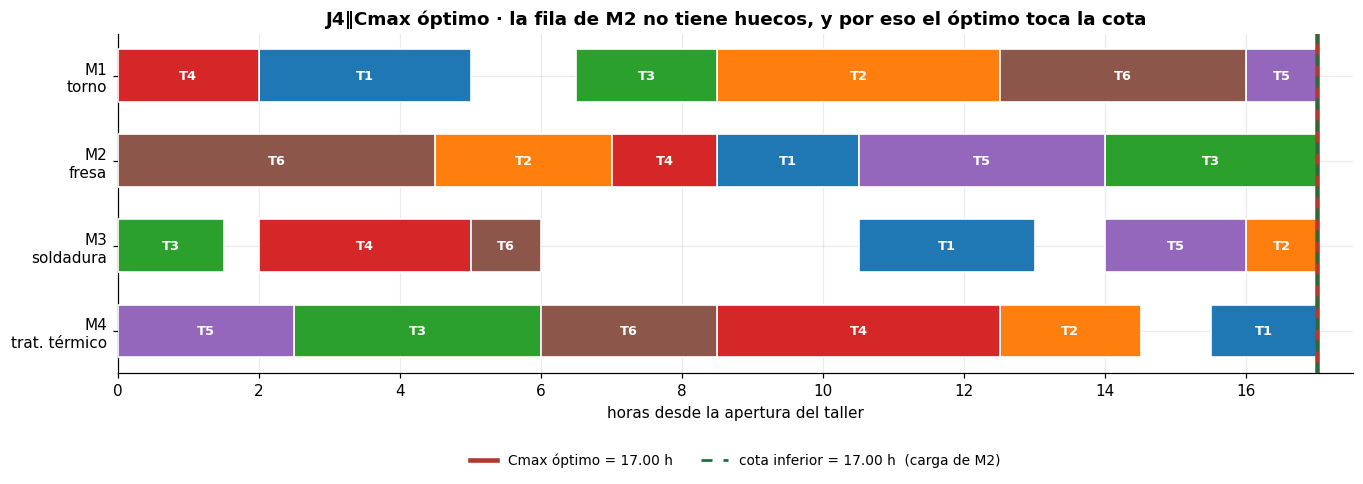

In [10]:
mapa = plt.get_cmap("tab10")
color_trabajo = {j: mapa(i % 10) for i, j in enumerate(TRABAJOS)}

fig, ax = plt.subplots(figsize=(12.5, 4.6))
for _, fila in asig.iterrows():
    y = MAQUINAS.index(fila.maquina)
    ancho = fila.fin - fila.inicio
    ax.barh(y, ancho, left=fila.inicio, height=0.62,
            color=color_trabajo[fila.trabajo], edgecolor="white",
            linewidth=1.1, zorder=3)
    ax.text(fila.inicio + ancho / 2, y, fila.trabajo, ha="center", va="center",
            color="white", fontsize=8.5, fontweight="bold", zorder=4)

ax.set_yticks(range(len(MAQUINAS)))
ax.set_yticklabels([f"{m}\n{NOMBRE_MAQ[m]}" for m in MAQUINAS])
ax.invert_yaxis()
ax.set_xlim(0, sol["Cmax"] * 1.03)
ax.set_xlabel("horas desde la apertura del taller")
ax.axvline(sol["Cmax"], color="#b03a2e", lw=3.0, zorder=5,
           label=f"Cmax óptimo = {sol['Cmax']:.2f} h")
ax.axvline(LB, color="#1f6f3d", lw=1.8, ls=(0, (4, 4)), zorder=6,
           label=f"cota inferior = {LB:.2f} h  (carga de {maq_critica})")
ax.set_title(f"J4‖Cmax óptimo · la fila de {maq_critica} no tiene huecos, "
             f"y por eso el óptimo toca la cota")
ax.legend(fontsize=9, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.20))
ax.grid(axis="x", alpha=0.25)

figura(fig, "gantt_jobshop")
plt.show()

### La ruta de cada trabajo, leída del mismo calendario

El Gantt de arriba se ordena por máquina. El mismo plan ordenado por trabajo
muestra la otra mitad de la historia: cuánto tiempo pasa cada pieza esperando
entre dos operaciones suyas. Esa espera es inventario en proceso, y es un
costo que el objetivo `Cmax` **no** está mirando.

In [11]:
print("Recorrido de cada trabajo (y su tiempo de espera entre operaciones):\n")
filas_flujo = []
for j in TRABAJOS:
    sub = asig[asig.trabajo == j].sort_values("k")
    espera = 0.0
    anterior_fin = 0.0
    for x in sub.itertuples():
        espera += x.inicio - anterior_fin
        anterior_fin = x.fin
    filas_flujo.append({"trabajo": j, "inicio": float(sub.inicio.min()),
                        "fin": float(sub.fin.max()),
                        "proceso_h": float(sub.p_h.sum()),
                        "espera_h": espera,
                        "flujo_h": float(sub.fin.max())})
flujo = pd.DataFrame(filas_flujo)
print(flujo.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print(f"\nΣ Cj = {flujo.fin.sum():.2f} h.  Minimizar Cmax no minimiza esto:")
print("son dos objetivos distintos sobre el mismo taller, como en el cuaderno 01.")

Recorrido de cada trabajo (y su tiempo de espera entre operaciones):

trabajo  inicio   fin  proceso_h  espera_h  flujo_h
     T1    2.00 17.00       9.00      8.00    17.00
     T2    4.50 17.00       9.50      7.50    17.00
     T3    0.00 17.00      10.00      7.00    17.00
     T4    0.00 12.50      10.50      2.00    12.50
     T5    0.00 17.00       9.00      8.00    17.00
     T6    0.00 16.00      11.50      4.50    16.00

Σ Cj = 96.50 h.  Minimizar Cmax no minimiza esto:
son dos objetivos distintos sobre el mismo taller, como en el cuaderno 01.


## 8. Comprobación

El valor que informa Gurobi es el de *su* función objetivo. Que ese número
describa el calendario que devuelve es otra afirmación, y se comprueba
recorriendo el calendario: ninguna máquina con dos operaciones a la vez,
ninguna ruta violada, y el makespan recalculado desde los `fin`.

In [12]:
print("Comprobación:")
ok = []
ok.append(verificar(lb_carga, 17.00, "cota por carga de máquina (h)", tol=1e-9))
ok.append(verificar(lb_ruta, 11.50, "cota por ruta más larga (h)", tol=1e-9))
ok.append(verificar(LB, 17.00, "cota inferior (h)", tol=1e-9))
ok.append(verificar(UB, 21.50, "despacho no-demora (h)", tol=1e-9))
ok.append(verificar(sol["Cmax"], 17.00, "óptimo J4||Cmax (h)", tol=1e-6))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

# --- el calendario es un calendario
assert sol["estado"] == "OPTIMAL", "el modelo debería cerrar en óptimo"
assert sol["gap_%"] < 1e-4, "gap no cerrado"
assert sol["binarias"] == len(MAQUINAS) * (len(TRABAJOS) * (len(TRABAJOS) - 1)) // 2, \
    "una binaria por par de operaciones que comparten máquina"

for m in MAQUINAS:
    sub = asig[asig.maquina == m].sort_values("inicio")
    for a, b in zip(sub.itertuples(), list(sub.itertuples())[1:]):
        assert b.inicio >= a.fin - 1e-6, f"solapamiento en {m}"
for j in TRABAJOS:
    sub = asig[asig.trabajo == j].sort_values("k")
    for k, x in enumerate(sub.itertuples()):
        assert x.maquina == maq[j, k], f"la operación {j}.{k+1} está en la máquina equivocada"
        assert abs((x.fin - x.inicio) - p[j, k]) < 1e-6, f"duración errónea en {j}.{k+1}"
    for a, b in zip(sub.itertuples(), list(sub.itertuples())[1:]):
        assert b.inicio >= a.fin - 1e-6, f"ruta violada en {j}"
assert abs(float(asig.fin.max()) - sol["Cmax"]) < 1e-6, \
    "el Cmax del calendario no coincide con el del solver"
assert sol["Cmax"] >= LB - 1e-6, "el óptimo no puede estar bajo la cota"

# --- la cota se alcanza: la maquina critica no tiene huecos
sub_c = asig[asig.maquina == maq_critica].sort_values("inicio")
assert abs(float(sub_c.inicio.min())) < 1e-6, \
    f"si la cota se alcanza, {maq_critica} debe arrancar en t = 0"
assert abs(float(sub_c.fin.max()) - sol["Cmax"]) < 1e-6, \
    f"si la cota se alcanza, {maq_critica} debe cerrar justo en Cmax"
huecos_criticos = float((sub_c.fin.max() - sub_c.inicio.min()) - sub_c.p_h.sum())
assert abs(huecos_criticos) < 1e-6, \
    f"si la cota se alcanza, {maq_critica} no puede tener huecos"
print(f"Calendario verificado: sin solapamientos, rutas respetadas, y "
      f"{maq_critica} sin un solo hueco.")

# --- y esto NO es un flow shop
assert not es_flowshop, "el archivo debería traer rutas distintas por trabajo"

tabla(asig.sort_values(["maquina", "inicio"]), "jobshop_programa_optimo")
tabla(ocup, "jobshop_ocupacion_maquinas")
tabla(flujo, "jobshop_flujo_trabajos")
tabla(bigM_df, "jobshop_bigM")
resumen({"cota_carga_maquina": float(lb_carga), "maquina_critica": maq_critica,
         "cota_ruta_larga": float(lb_ruta), "trabajo_critico": trab_critico,
         "cota_inferior": float(LB), "no_demora": float(UB),
         "optimo_J4_Cmax": float(sol["Cmax"]),
         "bigM_trivial": float(M_trivial), "bigM_ajustado": float(M_ajustado),
         "binarias": sol["binarias"], "restricciones": sol["restr"],
         "sumC": float(flujo.fin.sum())},
        "resumen_jobshop")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] cota por carga de máquina (h): obtenido 17.0000 | referencia 17.0000 | dif. relativa 0.00e+00
  [  OK  ] cota por ruta más larga (h): obtenido 11.5000 | referencia 11.5000 | dif. relativa 0.00e+00
  [  OK  ] cota inferior (h): obtenido 17.0000 | referencia 17.0000 | dif. relativa 0.00e+00
  [  OK  ] despacho no-demora (h): obtenido 21.5000 | referencia 21.5000 | dif. relativa 0.00e+00
  [  OK  ] óptimo J4||Cmax (h): obtenido 17.0000 | referencia 17.0000 | dif. relativa 0.00e+00

5/5 comprobaciones correctas
Calendario verificado: sin solapamientos, rutas respetadas, y M2 sin un solo hueco.

Guardado en resultados/


---

## Para llevarse

1. **El job shop no trae ninguna restricción nueva.** Es el mismo modelo
   disyuntivo del cuaderno 04 con otra tabla de rutas. Lo único que la
   generalización se lleva por delante es la cota fina del flow shop —la que
   sumaba el ocio de los extremos—, porque esa sí usaba que todos los lotes
   llegaran a cada etapa con la misma historia. Y el `prmu` deja de existir:
   sin una ruta común, "el orden de los trabajos" no es un objeto.
2. **El big-M se calcula, no se elige.** Cualquier cota superior del horizonte
   sirve, y la más barata sale de la heurística que igual hay que correr: 21,5
   en vez de 59,5. Pero el beneficio de apretarlo es **dependiente de la
   instancia**, y acá se midió y resultó nulo, porque en el rango válido de
   `M` la relajación lineal de la formulación disyuntiva no ve las máquinas.
   Esa debilidad no se arregla con un `M` mejor: se arregla con otra
   formulación.
3. **Un calendario no-demora es factible y puede ser malo.** 21,5 contra 17,0
   es un 26 % de exceso. En un job shop, además, *ningún* calendario
   no-demora es necesariamente óptimo: a veces conviene dejar una máquina
   parada esperando un trabajo que viene, y una regla que nunca lo hace no
   puede encontrar ese plan.
4. **Una cota que se alcanza convierte un resultado numérico en un argumento
   de gestión.** 17,00 = 17,00 no dice solo "este plan es óptimo": dice que la
   fresa está ocupada el 100 % del horizonte y que la única palanca real es
   descargarla. Esa frase se puede sostener frente a mantención sin haber
   probado ningún plan alternativo, y es más útil que el plan mismo.

## Ejercicios

1. La cota vale 17,00 h porque M2 acumula 17,00 h de carga. Mueva la operación
   de 4,5 h de T6 de M2 a M3 (que solo tiene 11,0 h de carga) y vuelva a
   correr. Prediga la nueva cota **antes** de ejecutar, y después compare con
   el óptimo: ¿se sigue alcanzando? Si no, ¿qué la volvió floja?
2. El despacho no-demora dio 21,50 h. Construya una instancia pequeña —tres
   trabajos, dos máquinas bastan— en que **todo** calendario no-demora sea
   estrictamente peor que el óptimo. Pista: necesita que convenga dejar una
   máquina parada esperando un trabajo corto que viene en camino.
3. Cambie el objetivo a `ΣCj` usando la columna `fin` de cada trabajo.
   ¿Coincide el plan con el de `Cmax`? Mire la columna `espera_h` de la
   sección 7 antes y después: ¿qué objetivo produce menos inventario en
   proceso, y por qué no es el mismo que el que ocupa mejor las máquinas?